## Tarea M21-CD - YAIR PALOMARES

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("C:/Users/yair_/OneDrive/Desktop/Ciencia de Datos/Módulo 21 - KNN y métricas de clasificación")

In [44]:
data = pd.read_csv("recursos_humanos.csv")
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [45]:
#Normalización de columnas faltantes
data["average_montly_hours"] = (data["average_montly_hours"] - np.min(data["average_montly_hours"])) / (np.max(data["average_montly_hours"]) - np.min(data["average_montly_hours"]))
data["time_spend_company"] = (data["time_spend_company"] - np.min(data["time_spend_company"])) / (np.max(data["time_spend_company"]) - np.min(data["time_spend_company"]))

#Se crean las variables dummy para las variables categóricas
number_project_dummy = pd.get_dummies(data["number_project"], prefix="Project", dtype= np.uint8)
number_sales_dummy = pd.get_dummies(data["sales"], prefix="Sales", dtype = np.uint8)
number_salary_dummy = pd.get_dummies(data["salary"], prefix="Salary", dtype = np.uint8)

#Se concatenan las columnas de las variables dummy creadas
data = pd.concat([data, number_project_dummy], axis=1)
data = pd.concat([data, number_sales_dummy], axis=1)
data = pd.concat([data, number_salary_dummy], axis=1)
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,...,Sales_hr,Sales_management,Sales_marketing,Sales_product_mng,Sales_sales,Sales_support,Sales_technical,Salary_high,Salary_low,Salary_medium
0,0.38,0.53,2,0.285047,0.125,0,1,0,sales,low,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,0.775701,0.500,0,1,0,sales,medium,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,0.822430,0.250,0,1,0,sales,medium,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,0.593458,0.375,0,1,0,sales,low,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,0.294393,0.125,0,1,0,sales,low,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,0.257009,0.125,0,1,0,support,low,...,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,0.299065,0.125,0,1,0,support,low,...,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,0.219626,0.125,0,1,0,support,low,...,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,0.859813,0.250,0,1,0,support,low,...,0,0,0,0,0,1,0,0,1,0


C:\Users\yair_\AppData\Local\Temp\ipykernel_18856\3730828639.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frec_left = pd.value_counts(data["left"])


<function matplotlib.pyplot.show(close=None, block=None)>

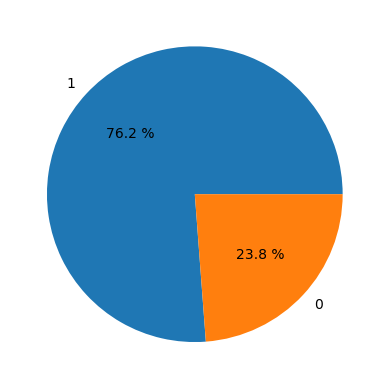

In [46]:
#Análisis exploratorio de los datos para validar equilibrio
frec_left = pd.value_counts(data["left"])
etiquetas = list(data['left'].unique())
plt.pie(frec_left, labels=etiquetas , autopct="%0.1f %%")
plt.show

In [47]:
#Se eliminan las columnas de las variables categóricas
data.drop(["number_project", "sales", "salary"], axis=1, inplace=True)

In [62]:
#Se definen variables dependientes e independientes
y = data.left.values
x = data.drop(["left"], axis=1)

#Base de entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=1)

#Modelo KNN (K vecinos más cercanos)
from sklearn.neighbors import KNeighborsClassifier

scores = {}
for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    prediction = knn.predict(x_test)
    scores[str(i)] = knn.score(x_test, y_test)

In [73]:
#Tabla de evaluación de 1-20 vecinos
evaluation_table = pd.DataFrame([scores]).transpose()
evaluation_table.columns = ["Evaluación"]
evaluation_table

,Evaluación
1,0.958000
2,0.954667
3,0.939333
4,0.942667
5,0.936667
6,0.940222
7,0.931556
8,0.930667
9,0.927111
10,0.927778


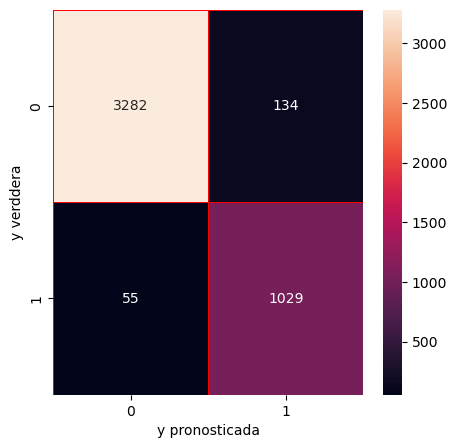

In [74]:
#Modelo KNN con el valor óptimo de K=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)
prediction = knn.predict(x_test)
scores[str(i)] = knn.score(x_test, y_test)

y_pred = prediction
y_true = y_test

#Creación de la matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

#Visualización de la matriz de confusión
import seaborn as sns
f, ax = plt.subplots(figsize = (5, 5))
sns. heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y verddera")
plt.show()

#### Cuando el algoritmo pronosticó que el empleado no renuncia, acertó en 3,282 ocasiones, mientras que falló en 55. Por otro lado, cuando el algoritmo pronosticó que el empleado renunciaba, logró acertar en 1,029 ocasiones y fallar en 134.

In [75]:
#Cálculo de la precisión global
correctos = cm[0,0] + cm[1,1]
incorrectos = cm[0,1] + cm[1,0]
PrecisionGlobal = correctos / (correctos + incorrectos)

#Precisión de que no renuncie
Precision_NoRenuncia = cm[0,0] / (cm[0,0] + cm[1,0])

#Precisión de que renuncie
Precision_Renuncia = cm[1,1] / (cm[0,1] + cm[1,1])

print("Precisión Global del Algoritmo = ", PrecisionGlobal)
print("Precisión para predecir cuando un empleado No Renuncia = ", Precision_NoRenuncia)
print("Precisión para predecir cuando un empleado Renuncia = ", Precision_Renuncia)

Precisión Global del Algoritmo =  0.958
Precisión para predecir cuando un empleado No Renuncia =  0.9835181300569373
Precisión para predecir cuando un empleado Renuncia =  0.884780739466896


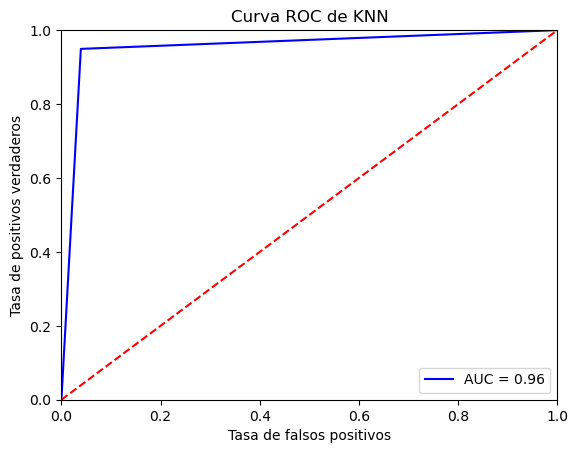

In [76]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_scores = knn.predict_proba(x_test)

fpr, tpr, threshold = roc_curve(y_test, y_scores[:,1])
# fpr = False Positive Rate
# tpr = True Positive Rate
roc_auc = auc(fpr, tpr)

plt.title("Receiver Operating Characteristic")
plt.plot(fpr, tpr, "b", label="AUC = %0.2f" % roc_auc)
plt.legend(loc = "lower right")
plt.plot([0,1], [0,1], "r--")
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel("Tasa de positivos verdaderos")
plt.xlabel("Tasa de falsos positivos")
plt.title("Curva ROC de KNN")
plt.show()